# numpyro: truncated distributions and circular data

Two places where numpyro users have hit missing special functions:

- Truncated distributions beyond the normal (numpyro#1365) need a
  differentiable CDF and quantile for the base distribution. chebax
  supplies both for Beta and Student-t.
- The von Mises distribution ships with a sampler but no CDF or
  quantile, so there is no reparameterized (pathwise) sampling and no
  probability-integral transform.

This notebook needs the `examples` extra: `pip install chebax[examples]`.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import chebax

## A truncated Student-t distribution for numpyro

`chebax.numpyro` ships this class ready-made (along with TruncatedGamma
and TruncatedBeta; `pip install chebax[numpyro]`). The construction it
packages is the textbook one below.

With F = `stdtr` and F^{-1} = `stdtrit`, truncation to [lo, hi] is the
textbook construction: sampling maps a uniform through the quantile, and
the log density subtracts the log normalization. Both parts are
differentiable in the degrees of freedom, so the distribution works as a
likelihood in NUTS with df as a latent.

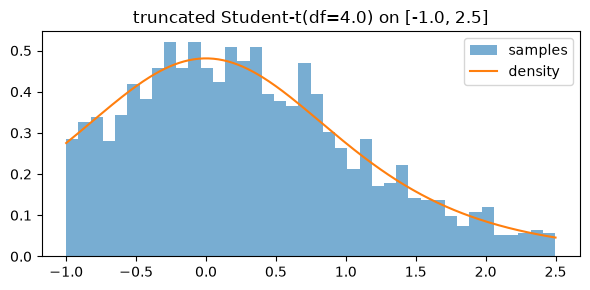

In [2]:
from chebax.numpyro import TruncatedStudentT

# reparameterized inverse-CDF sampling: u -> stdtrit(df, F(lo) + u*(F(hi)-F(lo)));
# log_prob subtracts the log truncation mass and is -inf outside [lo, hi]

lo, hi = -1.0, 2.5
true_df = 4.0
y = TruncatedStudentT(true_df, low=lo, high=hi).sample(jax.random.PRNGKey(1), (2000,))

plt.figure(figsize=(6, 3))
plt.hist(np.asarray(y), bins=40, density=True, alpha=0.6, label="samples")
tg = np.linspace(lo, hi, 300)
plt.plot(tg, np.exp(TruncatedStudentT(true_df, low=lo, high=hi).log_prob(tg)), label="density")
plt.legend()
plt.title(f"truncated Student-t(df={true_df}) on [{lo}, {hi}]")
plt.tight_layout()

## Recovering the degrees of freedom with NUTS

The classic hard case: df is weakly identified and enters the likelihood
only through the special functions. NUTS needs gradients of `stdtr` in
df, which is exactly what chebax provides.

In [3]:
def model(y):
    df = numpyro.sample("df", dist.Uniform(1.0, 15.0))
    numpyro.sample("y", TruncatedStudentT(df, low=lo, high=hi), obs=y)


mcmc = MCMC(NUTS(model), num_warmup=500, num_samples=500, progress_bar=False)
mcmc.run(jax.random.PRNGKey(2), y)
df_post = mcmc.get_samples()["df"]
print(f"true df: {true_df}")
print(f"posterior: mean {float(df_post.mean()):.2f}, "
      f"90% interval [{float(np.quantile(df_post, 0.05)):.2f}, "
      f"{float(np.quantile(df_post, 0.95)):.2f}]")

true df: 4.0


posterior: mean 5.23, 90% interval [2.41, 10.65]


## Reparameterized sampling gradients

The same construction gives pathwise gradients through a Monte Carlo
expectation, e.g. the mean of the truncated distribution as a function
of df. This is the mechanism numpyro's `TruncatedDistribution` uses for
the normal, now available for Student-t and Beta.

In [4]:
u = jax.random.uniform(jax.random.PRNGKey(3), (20000,))

def truncated_mean(df):
    # the class's icdf is the same stdtr/stdtrit construction
    return TruncatedStudentT(df, low=lo, high=hi).icdf(u).mean()

g = jax.grad(truncated_mean)(true_df)
h = 1e-4
fd = (truncated_mean(true_df + h) - truncated_mean(true_df - h)) / (2 * h)
print(f"d E[y]/d df: pathwise grad {float(g):+.6f}, finite diff {float(fd):+.6f}")

d E[y]/d df: pathwise grad -0.005122, finite diff -0.005122


## Von Mises: CDF, quantile, and pathwise gradients in kappa

`vonmises_cdf(kappa, theta)` and `vonmises_icdf(kappa, p)` cover the
circular distribution numpyro can sample but not evaluate. The CDF is
traced in kappa, so the concentration is learnable.

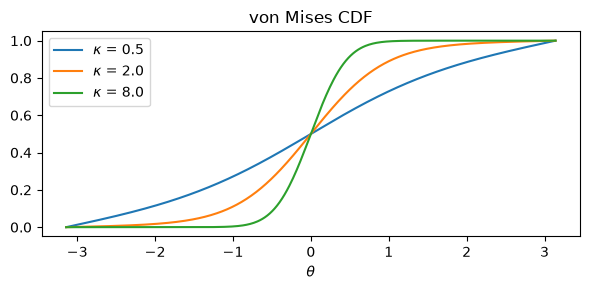

In [5]:
th = np.linspace(-np.pi, np.pi, 400)
plt.figure(figsize=(6, 3))
for kappa in [0.5, 2.0, 8.0]:
    plt.plot(th, chebax.vonmises_cdf(kappa, th), label=f"$\\kappa$ = {kappa}")
plt.xlabel(r"$\theta$")
plt.legend()
plt.title("von Mises CDF")
plt.tight_layout()

Inverse-CDF sampling agrees with numpyro's rejection sampler, and unlike
it, is differentiable in kappa. The check below uses the closed form
E[cos theta] = I_1(kappa)/I_0(kappa) = A(kappa), whose derivative is
A' = 1 - A/kappa - A^2. Both sides of the comparison come from chebax:
the left from pathwise gradients of the quantile, the right from
`besseli_ratio`, which computes I_{v+1}/I_v with the underflowing
prefactors cancelled analytically (a raw ratio of two `besseli_fn`
calls returns nan for small kappa in float32).

In [6]:
kappa0 = 2.0
u = jax.random.uniform(jax.random.PRNGKey(4), (40000,))

def mean_cos(kappa):
    return jnp.cos(chebax.vonmises_icdf(kappa, u)).mean()

def A(kappa):
    return chebax.besseli_ratio(0.0, kappa)

a0 = float(A(kappa0))
print(f"E[cos]: MC {float(mean_cos(kappa0)):.5f}, exact A(kappa) {a0:.5f}")
print(f"d E[cos]/d kappa: pathwise {float(jax.grad(mean_cos)(kappa0)):.5f}, "
      f"exact {1.0 - a0 / kappa0 - a0 ** 2:.5f}")

E[cos]: MC 0.69813, exact A(kappa) 0.69777


d E[cos]/d kappa: pathwise 0.16385, exact 0.16422


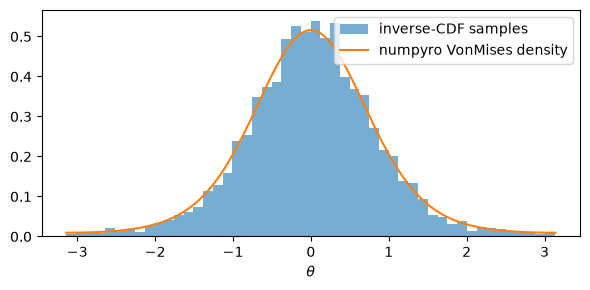

In [7]:
samples = chebax.vonmises_icdf(kappa0, jax.random.uniform(jax.random.PRNGKey(5), (8000,)))
ref = dist.VonMises(0.0, kappa0)
plt.figure(figsize=(6, 3))
plt.hist(np.asarray(samples), bins=50, density=True, alpha=0.6,
         label="inverse-CDF samples")
plt.plot(th, np.exp(ref.log_prob(th)), label="numpyro VonMises density")
plt.xlabel(r"$\theta$")
plt.legend()
plt.tight_layout()